In [78]:
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [79]:
df = pd.read_csv('/Users/sa03/Phase-1-Portfolio-Project/data/facebook_data_cleaned.csv', index_col=0)   

In [80]:
df.head()

,Page total likes,Type,Post Month,Post Weekday,Post Hour,Paid,Total Interactions,Log_Interactions,Type_Grouped_Visual,Category_2,Category_3,Post_Time_Period_Evening,Post_Time_Period_Morning,Post_Time_Period_Night
0,139441,Photo,12,4,3,0,100,4.615121,True,True,False,False,False,True
1,139441,Status,12,3,10,0,164,5.105945,False,True,False,False,True,False
2,139441,Photo,12,3,3,0,80,4.394449,True,False,True,False,False,True
3,139441,Photo,12,2,10,1,1777,7.483244,True,True,False,False,True,False
4,139441,Photo,12,2,3,0,393,5.976351,True,True,False,False,False,True


In [81]:
feature_cols = [col for col in df.columns if col not in ["Total Interactions", "Log_Interactions","Type"]]

X = df[feature_cols]
y = df["Log_Interactions"]

Train - Test split

Here we keep 20% of the data aside to evaluate how well the model generalizes to unseen post

In [82]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
#Now let's train our linear regression model.

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [84]:
#Now to making prediction with our log-interaction for the test posts.

y_pred = lr.predict(x_test)

In [85]:
#Lets evaluate our model using R-squared and RMSE(root mean squared error)

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"R^2:",r2)
print(f"RMSE(log scale):", rmse)

R^2: 0.06927336164997011
RMSE(log scale): 0.9932473367903463


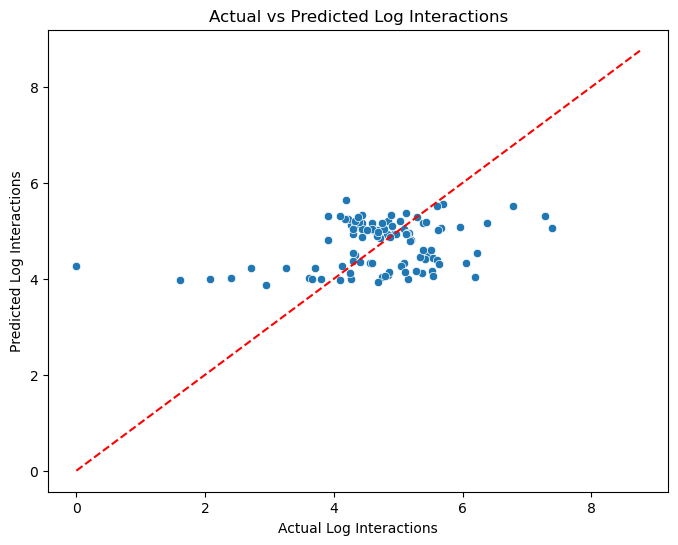

In [86]:
#Making a diagnostic plot to visualize the predicted vs actual of our model.

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Log Interactions")
plt.ylabel("Predicted Log Interactions")
plt.title("Actual vs Predicted Log Interactions")
plt.show()

The fit of our model looks like most of the data points are all clustered tightly around the line.

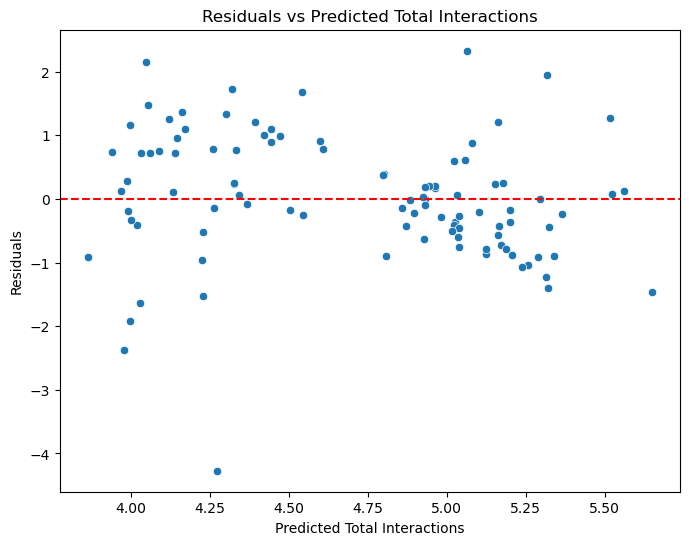

In [87]:
#Lets check if our model erroer are random or patterned by plotting the residuals.

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=y_test - y_pred)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Total Interactions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Total Interactions")
plt.show()

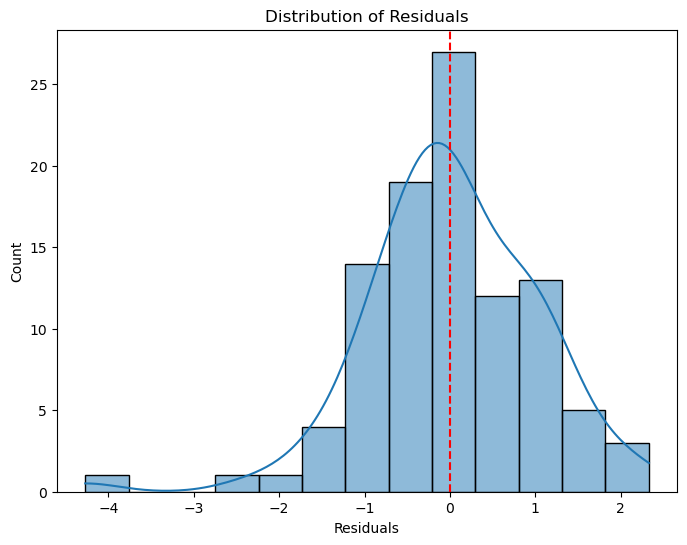

In [88]:
#Lets plot a residual histigram with a vertical line at 0 to check if the errors are centered around 0.

plt.figure(figsize=(8, 6))
sns.histplot(y_test - y_pred, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

### Overall Analysis

Based on my  model, my R^2 score was only 0.069 which means that the linear regression model explains only 6.9% of the variance in facebook post interactions. This is to say that the features I used (post type,posting time,paid status,etc) have very limited predictive power in the relationship between them and our target.

Also we had an RMSE of 0.993 on the log scale which further shows that our predictions deviate from the true values.

Finally this means that our model cannot reliably predict exact engagements with the given columns.